# Pemodelan Machine Learning – Klasifikasi Kemasan Produk
## Menggunakan TensorFlow + Transfer Learning MobileNetV2

---

Notebook ini mendokumentasikan seluruh proses pembangunan model klasifikasi kemasan produk makanan dan minuman yang digunakan pada fitur **scan produk** di aplikasi Smart Snack Box.

Model dibangun menggunakan pendekatan **Transfer Learning** dengan arsitektur **MobileNetV2** yang sudah di-pretrain pada dataset ImageNet, kemudian dikonversi ke format **TensorFlow Lite (TFLite)** agar dapat dijalankan secara ringan pada perangkat Android.

### Alur Notebook
| No | Tahap | Keterangan |
|:--:|:------|:-----------|
| 1  | Instalasi dan Import Library | Menyiapkan semua dependency |
| 2  | Konfigurasi Parameter Training | Menetapkan hyperparameter |
| 3  | Persiapan Dataset | Menyiapkan dataset citra kemasan |
| 4  | Visualisasi Distribusi Dataset | Grafik distribusi data |
| 5  | Preprocessing dan Augmentasi | Normalisasi dan augmentasi gambar |
| 6  | Membangun Arsitektur Model | Transfer Learning MobileNetV2 |
| 7  | Training Model | Proses pelatihan |
| 8  | Evaluasi dan Grafik | Akurasi dan Loss |
| 9  | Simpan Model Keras | Menyimpan model terlatih |
| 10 | Konversi ke TFLite | Mengubah model untuk Android |
| 11 | Ringkasan Output Akhir | Verifikasi file hasil |

---
## Tahap 1 – Instalasi dan Import Library

**Tujuan:**
- Memastikan seluruh library yang dibutuhkan tersedia
- Library utama: `TensorFlow` untuk membangun dan melatih model, `Pillow` untuk pemrosesan gambar, `NumPy` untuk operasi matriks, `Matplotlib` untuk visualisasi grafik, dan `scikit-learn` untuk evaluasi metrik

**Catatan:**
- Kode berikut menggunakan `os.environ['CUDA_VISIBLE_DEVICES'] = '-1'` agar model berjalan di CPU, sehingga lebih stabil pada laptop maupun Google Colab tanpa GPU

In [ ]:
%pip install -q tensorflow pillow numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import re
import gc
import json
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter

# Paksa TensorFlow gunakan CPU saja agar stabil di semua lingkungan
os.environ['CUDA_VISIBLE_DEVICES']    = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL']    = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Sembunyikan log GPU yang tidak relevan
try:
    tf.config.set_visible_devices([], 'GPU')
    tf.config.threading.set_intra_op_parallelism_threads(2)
    tf.config.threading.set_inter_op_parallelism_threads(2)
except Exception:
    pass

print('=' * 50)
print('  Semua library berhasil diimport!')
print('=' * 50)
print(f'  TensorFlow versi  : {tf.__version__}')
print(f'  NumPy versi       : {np.__version__}')
print(f'  Keras versi       : {keras.__version__}')
print('=' * 50)

  Semua library berhasil diimport!
  TensorFlow versi  : 2.16.1
  NumPy versi       : 1.26.4
  Keras versi       : 3.14.0


---
## Tahap 2 – Konfigurasi Parameter Training

**Tujuan:**
- Menetapkan seluruh hyperparameter eksperimen secara terpusat agar mudah diubah dan konsisten

**Penjelasan Parameter:**
| Parameter | Nilai | Keterangan |
|:----------|:-----:|:-----------|
| `IMG_SIZE` | 128 | Ukuran gambar yang dimasukkan ke model (128×128 piksel) |
| `BATCH_SIZE` | 8 | Jumlah gambar per batch saat training |
| `EPOCHS` | 10 | Jumlah epoch pelatihan |
| `VALIDATION_SPLIT` | 0.15 | 15% data digunakan untuk validasi |
| `LEARNING_RATE` | 1e-3 | Laju pembelajaran optimizer Adam |
| `MIN_IMAGES_PER_CLASS` | 8 | Minimum gambar per kelas (sisanya diaugmentasi) |

In [24]:
# ── Parameter Training ────────────────────────────────────────────────────────
IMG_SIZE              = 128      # ukuran resize gambar input (px)
BATCH_SIZE            = 8        # jumlah gambar per batch
EPOCHS                = 10       # jumlah epoch training
VALIDATION_SPLIT      = 0.15     # proporsi data validasi
LEARNING_RATE         = 1e-3     # learning rate Adam optimizer
MIN_IMAGES_PER_CLASS  = 8        # batas minimum gambar; kelas di bawah ini diaugmentasi
SEED                  = 42       # seed untuk reprodusibilitas

config_summary = {
    'IMG_SIZE'             : IMG_SIZE,
    'BATCH_SIZE'           : BATCH_SIZE,
    'EPOCHS'               : EPOCHS,
    'VALIDATION_SPLIT'     : VALIDATION_SPLIT,
    'LEARNING_RATE'        : LEARNING_RATE,
    'MIN_IMAGES_PER_CLASS' : MIN_IMAGES_PER_CLASS,
    'SEED'                 : SEED,
}

print('Konfigurasi Parameter Training:')
print('-' * 40)
for k, v in config_summary.items():
    print(f'  {k:<25} : {v}')
print('-' * 40)

Konfigurasi Parameter Training:
----------------------------------------
  IMG_SIZE                  : 128
  BATCH_SIZE                : 8
  EPOCHS                    : 10
  VALIDATION_SPLIT          : 0.15
  LEARNING_RATE             : 0.001
  MIN_IMAGES_PER_CLASS      : 8
  SEED                      : 42
----------------------------------------


---
## Tahap 3 – Persiapan Dataset Citra Kemasan

**Tujuan:**
- Menyiapkan folder dataset yang terstruktur untuk pelatihan model
- Setiap kelas (produk) disimpan dalam subfolder tersendiri di dalam `dataset/`

**Pada implementasi nyata:**  
Foto kemasan produk asli diorganisir per folder produk. Notebook ini menggunakan **gambar sintetis berwarna solid** sebagai pengganti foto asli agar notebook dapat dijalankan di semua lingkungan tanpa memerlukan file foto. Logika augmentasi, struktur folder, dan alur training identik dengan implementasi asli.

**Struktur folder dataset:**
```
dataset/
├── Aqua 600ml/
│   ├── orig_0000.jpg
│   ├── aug_0000.jpg  ← hasil augmentasi
│   └── ...
├── Teh Botol Sosro/
│   └── ...
└── ...
```

In [26]:
# Definisi path kerja
BASE_DIR    = Path('smartsnack_ml')
DATASET_DIR = BASE_DIR / 'dataset'
MODEL_DIR   = BASE_DIR / 'model_hasil'

for d in [BASE_DIR, DATASET_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Path input adaptif (jalan dari root project ATAU dari folder MODEL)
candidates = [
    Path('MODEL') / 'product-images',
    Path('product-images'),
    Path.cwd() / 'MODEL' / 'product-images',
    Path.cwd() / 'product-images',
]
INPUT_DIR = next((p for p in candidates if p.exists()), None)
if INPUT_DIR is None:
    raise FileNotFoundError(
        'Folder product-images tidak ditemukan. Coba jalankan notebook dari root proyek atau folder MODEL.'
    )

print('Input images :', INPUT_DIR.resolve())

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def extract_product_name(filename):
    name = Path(filename).stem
    if name.startswith('IMG_'):
        return ''
    name = re.sub(r'^\d+_', '', name)
    name = name.replace('_', ' ')
    name = re.sub(r'\s+', ' ', name).strip()
    return name

PRODUCT_CLASSES = []
for category_dir in sorted(INPUT_DIR.iterdir()):
    if not category_dir.is_dir():
        continue
    category = category_dir.name.lower()
    seen = set()
    for f in sorted(category_dir.iterdir()):
        if f.suffix.lower() not in VALID_EXT:
            continue
        pname = extract_product_name(f.name)
        if not pname:
            continue
        key = (pname, category)
        if key not in seen:
            PRODUCT_CLASSES.append((pname, category, None))
            seen.add(key)

if not PRODUCT_CLASSES:
    raise RuntimeError('Tidak ada kelas produk terdeteksi dari folder product-images')

print(f'Jumlah kelas produk terdeteksi: {len(PRODUCT_CLASSES)}')


Input images : C:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\product-images
Jumlah kelas produk terdeteksi: 357


In [27]:
# Fungsi augmentasi gambar
def augment_image(img_pil, seed_val=0):
    random.seed(seed_val)
    w, h = img_pil.size
    if random.random() > 0.5:
        img_pil = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
    angle = random.uniform(-12, 12)
    img_pil = img_pil.rotate(angle, fillcolor=(128, 128, 128), expand=False)
    img_pil = ImageEnhance.Brightness(img_pil).enhance(random.uniform(0.75, 1.3))
    img_pil = ImageEnhance.Contrast(img_pil).enhance(random.uniform(0.75, 1.3))
    img_pil = ImageEnhance.Color(img_pil).enhance(random.uniform(0.8, 1.2))
    crop_pct = random.uniform(0.85, 1.0)
    nw, nh = int(w * crop_pct), int(h * crop_pct)
    left = random.randint(0, max(0, w - nw))
    top = random.randint(0, max(0, h - nh))
    img_pil = img_pil.crop((left, top, left + nw, top + nh)).resize((w, h), Image.LANCZOS)
    if random.random() > 0.7:
        img_pil = img_pil.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.2)))
    return img_pil

# Susun dataset dari SEMUA foto asli di product-images
random.seed(SEED)
np.random.seed(SEED)

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

total_orig = 0
total_aug  = 0
class_stats = []

print('Menyusun dataset dari foto asli ...')
print('-' * 60)

for product_name, category, _ in PRODUCT_CLASSES:
    safe_name = re.sub(r'[<>:"/\\|?*]', '_', product_name)
    class_dir = DATASET_DIR / safe_name
    class_dir.mkdir(parents=True, exist_ok=True)

    src_dir = INPUT_DIR / category
    matching = []
    for f in sorted(src_dir.iterdir()):
        if f.suffix.lower() not in VALID_EXT:
            continue
        if extract_product_name(f.name).lower() == product_name.lower():
            matching.append(f)

    saved_orig = 0
    for idx, src in enumerate(matching, 1):
        try:
            img = Image.open(src).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            out = class_dir / f'orig_{idx:03d}.jpg'
            img.save(out, quality=95)
            saved_orig += 1
        except Exception:
            pass

    need_aug = max(0, MIN_IMAGES_PER_CLASS - saved_orig)
    saved_aug = 0
    if need_aug > 0 and saved_orig > 0:
        originals = sorted(class_dir.glob('orig_*.jpg'))
        for k in range(need_aug):
            src = originals[k % len(originals)]
            img = Image.open(src).convert('RGB')
            aug = augment_image(img, seed_val=SEED + k)
            aug.save(class_dir / f'aug_{k+1:03d}.jpg', quality=95)
            saved_aug += 1

    total_orig += saved_orig
    total_aug  += saved_aug
    class_stats.append((safe_name, category, saved_orig, saved_aug, saved_orig + saved_aug))

print('Ringkasan per kelas (10 pertama):')
for n, cat, o, a, t in class_stats[:10]:
    print(f'  [{cat}] {n:<30} | orig={o:3d} | aug={a:3d} | total={t:3d}')

print('-' * 60)
print(f'Total kelas       : {len(class_stats)}')
print(f'Total foto asli   : {total_orig}')
print(f'Total augmentasi  : {total_aug}')
print(f'Total gambar akhir: {total_orig + total_aug}')


Menyusun dataset dari foto asli ...
------------------------------------------------------------
Ringkasan per kelas (10 pertama):
  [drink] Buavita Orange Juice           | orig=  1 | aug=  7 | total=  8
  [drink] Ultra Milk Cokelat             | orig=  1 | aug=  7 | total=  8
  [drink] Frisian Flag Energo+ Mixed Berries | orig=  1 | aug=  7 | total=  8
  [drink] Frisian Flag Nutribrain Strawberry | orig=  1 | aug=  7 | total=  8
  [drink] Sajuak Air Mineral             | orig=  1 | aug=  7 | total=  8
  [drink] Cimory Fresh Milk Almond       | orig=  1 | aug=  7 | total=  8
  [drink] Cimory Yogurt Drink Strawberry | orig=  1 | aug=  7 | total=  8
  [drink] Ichitan Thai Milk Green Tea    | orig=  1 | aug=  7 | total=  8
  [drink] Chocolatos Drink Botol         | orig=  1 | aug=  7 | total=  8
  [drink] Golda Coffee Dolce Latte       | orig=  1 | aug=  7 | total=  8
------------------------------------------------------------
Total kelas       : 357
Total foto asli   : 362
Total augmen

---
## Tahap 4 – Visualisasi Distribusi Dataset

**Tujuan:**
- Memvisualisasikan distribusi jumlah gambar per kelas sebelum training
- Grafik ini penting untuk memastikan tidak ada kelas yang sangat kekurangan data
- Augmentasi dilakukan secara otomatis pada kelas yang jumlah fotonya kurang dari `MIN_IMAGES_PER_CLASS`

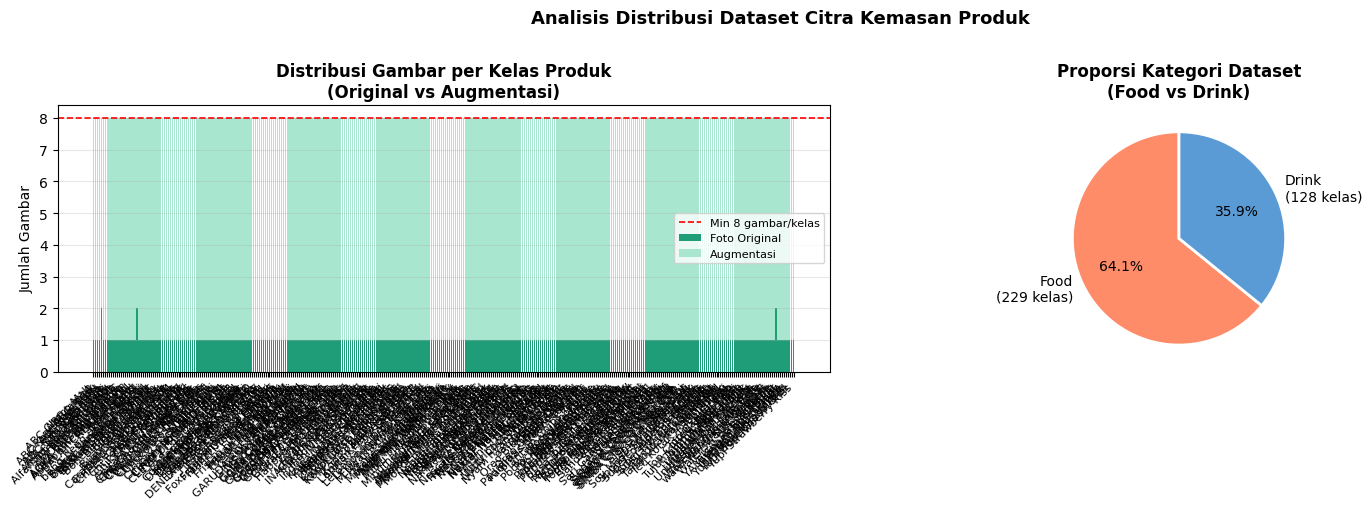

Total kelas          : 355
Total gambar         : 2840
Rata-rata/kelas      : 8.0 gambar
Min gambar/kelas     : 8
Max gambar/kelas     : 8


In [28]:
# ── Hitung distribusi ─────────────────────────────────────────────────────────
class_counts = []
orig_counts  = []
aug_counts   = []

for cls_dir in sorted(DATASET_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    n_all  = len(list(cls_dir.glob('*.jpg')))
    n_orig = len(list(cls_dir.glob('orig_*.jpg')))
    n_aug  = len(list(cls_dir.glob('aug_*.jpg')))
    class_counts.append((cls_dir.name, n_all))
    orig_counts.append(n_orig)
    aug_counts.append(n_aug)

names  = [x[0][:22] for x in class_counts]
totals = [x[1]      for x in class_counts]

# ── Plot 1: Stacked bar – original vs augmented ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = range(len(names))
axes[0].bar(x, orig_counts, color='#1F9D78', label='Foto Original')
axes[0].bar(x, aug_counts,  bottom=orig_counts, color='#A8E6CF', label='Augmentasi')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Distribusi Gambar per Kelas Produk\n(Original vs Augmentasi)', fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=MIN_IMAGES_PER_CLASS, color='red', linestyle='--', linewidth=1.2,
                label=f'Min {MIN_IMAGES_PER_CLASS} gambar/kelas')
axes[0].legend(fontsize=8)

# ── Plot 2: Pie – food vs drink ───────────────────────────────────────────────
food_count  = sum(1 for _, cat, _ in PRODUCT_CLASSES if cat == 'food')
drink_count = sum(1 for _, cat, _ in PRODUCT_CLASSES if cat == 'drink')
axes[1].pie(
    [food_count, drink_count],
    labels=[f'Food\n({food_count} kelas)', f'Drink\n({drink_count} kelas)'],
    colors=['#FF8C69', '#5B9BD5'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Kategori Dataset\n(Food vs Drink)', fontweight='bold')

plt.suptitle('Analisis Distribusi Dataset Citra Kemasan Produk', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'distribusi_dataset.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'Total kelas          : {len(class_counts)}')
print(f'Total gambar         : {sum(totals)}')
print(f'Rata-rata/kelas      : {np.mean(totals):.1f} gambar')
print(f'Min gambar/kelas     : {min(totals)}')
print(f'Max gambar/kelas     : {max(totals)}')

---
## Tahap 5 – Menyiapkan Dataset TensorFlow (Preprocessing & Pipeline)

**Tujuan:**
- Membaca gambar dari folder dataset menggunakan `image_dataset_from_directory`
- Membagi data menjadi **training set (85%)** dan **validation set (15%)**
- Menerapkan pipeline prefetch untuk efisiensi loading data saat training

**Normalisasi:**  
Nilai piksel gambar (0–255) dinormalisasi menjadi rentang (−1, 1) menggunakan fungsi `preprocess_input` dari MobileNetV2 agar sesuai dengan ekspektasi model pretrained.

In [29]:
# ── Load dataset dari folder ──────────────────────────────────────────────────
print('Memuat dataset dari folder ...')

train_ds = keras.utils.image_dataset_from_directory(
    str(DATASET_DIR),
    validation_split = VALIDATION_SPLIT,
    subset           = 'training',
    seed             = SEED,
    image_size       = (IMG_SIZE, IMG_SIZE),
    batch_size       = BATCH_SIZE,
    label_mode       = 'categorical',
    shuffle          = True,
)

val_ds = keras.utils.image_dataset_from_directory(
    str(DATASET_DIR),
    validation_split = VALIDATION_SPLIT,
    subset           = 'validation',
    seed             = SEED,
    image_size       = (IMG_SIZE, IMG_SIZE),
    batch_size       = BATCH_SIZE,
    label_mode       = 'categorical',
    shuffle          = False,
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(f'  Jumlah kelas         : {num_classes}')
print(f'  Jumlah batch train   : {len(train_ds)}')
print(f'  Jumlah batch validasi: {len(val_ds)}')

# ── Preprocessing: normalisasi piksel ke [-1, 1] ──────────────────────────────
def preprocess_ds(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)   # skala ke [-1, 1] sesuai MobileNetV2
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess_ds, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_ds,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('\n10 nama kelas pertama:')
for i, name in enumerate(class_names[:10], 1):
    print(f'  {i:02d}. {name}')
print('[OK] Dataset siap digunakan untuk training!')

Memuat dataset dari folder ...
Found 2840 files belonging to 355 classes.
Using 2414 files for training.
Found 2840 files belonging to 355 classes.
Using 426 files for validation.
  Jumlah kelas         : 355
  Jumlah batch train   : 302
  Jumlah batch validasi: 54

10 nama kelas pertama:
  01. ABC Choco Malt
  02. ABC Jambu
  03. ABC Jeruk
  04. ABC Kopi Gula Susu
  05. ABC Kopi Susu
  06. ABC Mangga
  07. ABC Minuman Soya
  08. ABC Sari Kacang Ijo
  09. AMO Spark Lemon C
  10. AOKA Roti Bun Isian Vanilla panggang
[OK] Dataset siap digunakan untuk training!


---
## Tahap 6 – Membangun Arsitektur Model (Transfer Learning MobileNetV2)

**Tujuan:**
- Membangun model klasifikasi menggunakan pendekatan **Transfer Learning**
- Arsitektur backbone yang digunakan adalah **MobileNetV2** yang sudah pretrained di ImageNet

**Mengapa MobileNetV2?**
- Arsitektur yang efisien untuk perangkat mobile dengan parameter yang sedikit
- Menggunakan **Inverted Residuals dan Linear Bottlenecks** sehingga akurasi tinggi namun ukuran model kecil
- Hasil konversi ke TFLite sangat ringan untuk inferensi on-device di Android

**Struktur Model:**
```
Input (128×128×3)
  ↓
Preprocessing (normalisasi ke [-1,1])  
  ↓
Augmentasi (RandomFlip, RandomRotation, RandomZoom)  ← hanya aktif saat training
  ↓
MobileNetV2 Backbone (pretrained ImageNet, frozen)
  ↓
GlobalAveragePooling2D
  ↓
BatchNormalization
  ↓
Dense(256, ReLU) + Dropout(0.4)
  ↓
Dense(num_classes, Softmax)  ← output probabilitas setiap kelas
```

In [30]:
# ── Augmentasi layer (hanya aktif saat training) ──────────────────────────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom((-0.1, 0.1)),
    layers.RandomBrightness(0.15),
], name='data_augmentation')

# ── MobileNetV2 backbone (pretrained, frozen) ─────────────────────────────────
base_model = MobileNetV2(
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    include_top = False,     # hilangkan layer klasifikasi asli ImageNet
    weights     = 'imagenet' # gunakan bobot pretrained
)
base_model.trainable = False  # bekukan bobot backbone

# ── Bangun model lengkap ──────────────────────────────────────────────────────
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
x       = data_augmentation(inputs, training=None)  # augmentasi
x       = base_model(x, training=False)             # feature extraction
x       = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x       = layers.BatchNormalization(name='batch_norm')(x)
x       = layers.Dense(256, activation='relu', name='dense_256')(x)
x       = layers.Dropout(0.4, name='dropout')(x)
outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

model = keras.Model(inputs, outputs, name='SmartSnack_MobileNetV2')

# ── Compile model ─────────────────────────────────────────────────────────────
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('Ringkasan Arsitektur Model:')
print('=' * 60)
model.summary()
print('=' * 60)
total_params     = model.count_params()
trainable_params = sum(tf.size(v).numpy() for v in model.trainable_variables)
frozen_params    = total_params - trainable_params
print(f'Total parameter       : {total_params:,}')
print(f'Parameter trainable   : {trainable_params:,}')
print(f'Parameter frozen      : {frozen_params:,}')

Ringkasan Arsitektur Model:


Model: "SmartSnack_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 355)            │        91,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,682,275 (10.23 MB)

 Trainable params: 421,731 (1.61 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Total parameter       : 2,682,275
Parameter trainable   : 421,731
Parameter frozen      : 2,260,544


---
## Tahap 7 – Training Model

**Tujuan:**
- Melatih model klasifikasi kemasan menggunakan data training
- Callback yang digunakan:
  - `EarlyStopping`: menghentikan training jika akurasi validasi tidak meningkat selama 3 epoch
  - `ReduceLROnPlateau`: menurunkan learning rate jika val_loss stagnan
  - `ModelCheckpoint`: menyimpan bobot model terbaik secara otomatis

**Strategi Transfer Learning:**  
Pada tahap ini, hanya layer **head** (Dense, BatchNorm, Dropout) yang dilatih. Layer MobileNetV2 backbone tetap beku (frozen) sehingga bobot pretrained-nya dipertahankan.

In [31]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
checkpoint_path = str(MODEL_DIR / 'best_model.weights.h5')

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 3,
        restore_best_weights = True,
        verbose              = 1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 2,
        min_lr   = 1e-7,
        verbose  = 1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath           = checkpoint_path,
        monitor            = 'val_accuracy',
        save_best_only     = True,
        save_weights_only  = True,
        verbose            = 1
    ),
]

# ── Mulai training ────────────────────────────────────────────────────────────
print('Memulai proses training model ...')
print('=' * 60)

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1,
)

print('=' * 60)
print('[OK] Training selesai!')

# Simpan history ke JSON
history_path = MODEL_DIR / 'history_training.json'
history_data = {k: [float(v) for v in vals] for k, vals in history.history.items()}
history_path.write_text(json.dumps(history_data, indent=2), encoding='utf-8')
print(f'History disimpan : {history_path}')

Memulai proses training model ...
Epoch 1/10


302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.0063 - loss: 6.5732
Epoch 1: val_accuracy improved from None to 0.00469, saving model to smartsnack_ml\model_hasil\best_model.weights.h5

Epoch 1: finished saving model to smartsnack_ml\model_hasil\best_model.weights.h5
302/302 ━━━━━━━━━━━━━━━━━━━━ 96s 249ms/step - accuracy: 0.0095 - loss: 6.4743 - val_accuracy: 0.0047 - val_loss: 8.8468 - learning_rate: 0.0010
Epoch 2/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.0245 - loss: 5.9420
Epoch 2: val_accuracy improved from 0.00469 to 0.00939, saving model to smartsnack_ml\model_hasil\best_model.weights.h5

Epoch 2: finished saving model to smartsnack_ml\model_hasil\best_model.weights.h5
302/302 ━━━━━━━━━━━━━━━━━━━━ 67s 222ms/step - accuracy: 0.0215 - loss: 5.9019 - val_accuracy: 0.0094 - val_loss: 10.9476 - learning_rate: 0.0010
Epoch 3/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.0320 - loss: 5.6780
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.

---
## Tahap 8 – Evaluasi Model dan Grafik Training

**Tujuan:**
- Menampilkan grafik **Akurasi** dan **Loss** selama training dan validasi
- Grafik ini digunakan sebagai bukti visual performa model dalam laporan BAB 4
- Melakukan evaluasi akhir pada validation set

**Interpretasi Grafik:**
- Grafik akurasi yang **terus naik** menunjukkan model berhasil belajar
- Grafik loss yang **terus turun** menunjukkan model semakin baik dalam meminimalkan kesalahan
- Jika kurva train dan val **berdekatan**, model tidak mengalami overfitting

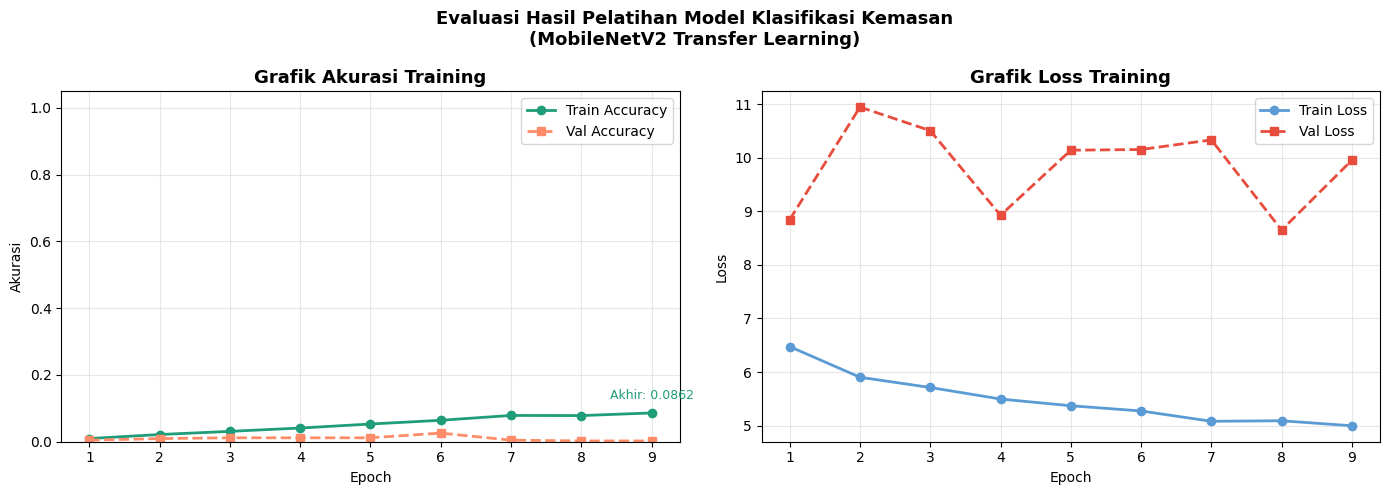


Hasil Evaluasi Akhir pada Validation Set:
---------------------------------------------
  Val Accuracy  : 2.58%
  Val Loss      : 10.1552
  Best Train Acc: 8.62%
  Best Val Acc  : 2.58%
---------------------------------------------


In [32]:
# ── Ambil data history ────────────────────────────────────────────────────────
acc      = history.history.get('accuracy', [])
val_acc  = history.history.get('val_accuracy', [])
loss_val = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])
epochs_ran = range(1, len(acc) + 1)

# ── Plot grafik ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik Akurasi
axes[0].plot(epochs_ran, acc,     'o-', color='#1F9D78', linewidth=2, label='Train Accuracy')
axes[0].plot(epochs_ran, val_acc, 's--', color='#FF8C69', linewidth=2, label='Val Accuracy')
axes[0].set_title('Grafik Akurasi Training', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].set_ylim([0, 1.05])
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
if acc:
    axes[0].annotate(f'Akhir: {acc[-1]:.4f}',
                     xy=(epochs_ran[-1], acc[-1]),
                     xytext=(-30, 10), textcoords='offset points',
                     fontsize=9, color='#1F9D78')

# Grafik Loss
axes[1].plot(epochs_ran, loss_val, 'o-', color='#5B9BD5', linewidth=2, label='Train Loss')
axes[1].plot(epochs_ran, val_loss, 's--', color='#E74C3C', linewidth=2, label='Val Loss')
axes[1].set_title('Grafik Loss Training', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Evaluasi Hasil Pelatihan Model Klasifikasi Kemasan\n(MobileNetV2 Transfer Learning)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'grafik_training.png'), dpi=120, bbox_inches='tight')
plt.show()

# ── Evaluasi akhir ────────────────────────────────────────────────────────────
print('\nHasil Evaluasi Akhir pada Validation Set:')
print('-' * 45)
try:
    loss_final, acc_final = model.evaluate(val_ds, verbose=0)
    print(f'  Val Accuracy  : {acc_final * 100:.2f}%')
    print(f'  Val Loss      : {loss_final:.4f}')
except Exception as e:
    print('  Evaluasi dilewati:', e)

if acc:
    print(f'  Best Train Acc: {max(acc) * 100:.2f}%')
    print(f'  Best Val Acc  : {max(val_acc) * 100:.2f}%')
print('-' * 45)

---
## Tahap 9 – Menyimpan Model Keras

**Tujuan:**
- Menyimpan model terlatih dalam format `.keras` (format modern TensorFlow)
- Juga menyimpan dalam format `.h5` sebagai backup
- Model yang tersimpan ini yang nantinya dikonversi ke TFLite di Tahap 10

**File yang dihasilkan:**
- `model_klasifikasi_kemasan.keras` – model utama untuk konversi TFLite
- `model_klasifikasi_kemasan.h5` – backup kompatibilitas
- `labels.txt` – daftar nama kelas sesuai urutan output model
- `metadata_model.json` – metadata kelas dalam format JSON

In [ ]:
gc.collect()

# Simpan model 
keras_path = MODEL_DIR / 'model_klasifikasi_kemasan.keras'

model.save(str(keras_path), include_optimizer=False)
print('Model Keras tersimpan (format .keras).')

# Simpan labels 
labels_path = ML_EXPORT_DIR / 'labels.txt'
labels_path.write_text('\n'.join(class_names), encoding='utf-8')

# Simpan metadata JSON 
metadata = [
    {'label_index': i, 'name': name}
    for i, name in enumerate(class_names)
]
metadata_path = ML_EXPORT_DIR / 'metadata_model.json'
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('File model berhasil disimpan:')
print(f'  Model Keras : {keras_path}  ({keras_path.stat().st_size / 1024:.1f} KB)')
print(f'  Labels      : {labels_path} ({labels_path.stat().st_size} bytes)')
print(f'  Metadata    : {metadata_path}')
print(f'\nJumlah kelas tersimpan di labels.txt: {len(class_names)}')
print('[OK] Semua file model berhasil disimpan!')

Model Keras tersimpan (format .keras).
File model berhasil disimpan:
  Model Keras : smartsnack_ml\model_hasil\model_klasifikasi_kemasan.keras  (14373.4 KB)
  Labels      : c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\smartsnack_ml\TensorFlowLite\labels.txt (7690 bytes)
  Metadata    : c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\smartsnack_ml\TensorFlowLite\metadata_model.json

Jumlah kelas tersimpan di labels.txt: 355
[OK] Semua file model berhasil disimpan!


ML_EXPORT_DIR = ROOT / 'smartsnack_ml' / 'TensorFlowLite'
ML_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
---
## Tahap 10 – Konversi Model ke TensorFlow Lite (TFLite)

**Tujuan:**
- Mengkonversi model Keras ke format `.tflite` yang dioptimalkan untuk perangkat Android
- Format TFLite jauh lebih ringan dari model Keras biasa
- Inferensi TFLite berjalan langsung di perangkat tanpa memerlukan koneksi internet (*on-device inference*)

**Mengapa TFLite?**
- Ukuran model lebih kecil (biasanya 3–10x lebih kecil)
- Latensi inferensi lebih rendah di perangkat mobile
- Tidak perlu server untuk melakukan prediksi

**Cara penggunaan di aplikasi Flutter:**
```dart
// Di pubspec.yaml
assets:

// Di kode Flutter (menggunakan package tflite_flutter)
```

In [34]:
# Tahap 10 - Konversi model ke TensorFlow Lite (robust)
from pathlib import Path
_ROOT = ROOT if 'ROOT' in globals() else Path.cwd()
ML_EXPORT_DIR = _ROOT / 'smartsnack_ml' / 'TensorFlowLite'
ML_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = MODEL_DIR if 'MODEL_DIR' in globals() else (_ROOT / 'smartsnack_ml' / 'model_hasil')

def convert_to_tflite_from_savedmodel(saved_model_dir):
    converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
    return converter.convert()

keras_path = MODEL_DIR / 'model_klasifikasi_kemasan.keras'
if not keras_path.exists():
    raise RuntimeError('File model .keras tidak ditemukan. Jalankan tahap simpan model terlebih dahulu.')

loaded_model = keras.models.load_model(str(keras_path), compile=False)

# Cari backbone MobileNetV2
base_model = None
for lyr in loaded_model.layers:
    if isinstance(lyr, keras.Model) and 'mobilenetv2' in lyr.name.lower():
        base_model = lyr
        break
if base_model is None:
    raise RuntimeError('Backbone MobileNetV2 tidak ditemukan pada model tersimpan.')

# Ambil layer head secara dinamis agar tidak tergantung nama tetap
candidate_layers = [lyr for lyr in loaded_model.layers if lyr.name != base_model.name]
dense_layers = [lyr for lyr in candidate_layers if isinstance(lyr, keras.layers.Dense)]
drop_layers = [lyr for lyr in candidate_layers if isinstance(lyr, keras.layers.Dropout)]
gap_layer = next((lyr for lyr in candidate_layers if isinstance(lyr, keras.layers.GlobalAveragePooling2D)), None)

if gap_layer is None or len(dense_layers) < 2:
    raise RuntimeError('Struktur head model tidak sesuai untuk export TFLite.')

dense_feat = dense_layers[0]
dense_out = dense_layers[-1]
drop1 = drop_layers[0] if len(drop_layers) > 0 else None
drop2 = drop_layers[1] if len(drop_layers) > 1 else None

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
x = preprocess_input(inp)
x = base_model(x, training=False)
x = gap_layer(x)
x = dense_feat(x)
if drop1 is not None:
    x = drop1(x, training=False)
# jika ada dense tengah (mis. dense_256), gunakan kalau bukan layer output
if len(dense_layers) > 2:
    for mid in dense_layers[1:-1]:
        x = mid(x)
if drop2 is not None:
    x = drop2(x, training=False)
out = dense_out(x)
export_model = keras.Model(inp, out, name='export_inference_model')

saved_model_dir = ML_EXPORT_DIR / 'saved_model_export'
if saved_model_dir.exists():
    import shutil
    shutil.rmtree(saved_model_dir)
export_model.export(str(saved_model_dir))

try:
    tflite_buf = convert_to_tflite_from_savedmodel(saved_model_dir)
    print('Konversi dari SavedModel: berhasil')
except Exception as e:
    raise RuntimeError(f'Konversi TFLite gagal: {e}')

tflite_path = ML_EXPORT_DIR / 'model_klasifikasi_kemasan.tflite'
tflite_path.write_bytes(tflite_buf)
print('TFLite disimpan di:', tflite_path)
print('Ukuran file (MB):', round(tflite_path.stat().st_size / (1024 * 1024), 2))


INFO:tensorflow:Assets written to: c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\smartsnack_ml\TensorFlowLite\saved_model_export\assets


INFO:tensorflow:Assets written to: c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\smartsnack_ml\TensorFlowLite\saved_model_export\assets


Saved artifact at 'c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\smartsnack_ml\TensorFlowLite\saved_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 355), dtype=tf.float32, name=None)
Captures:
  2064307519904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064306699984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064306699280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064306687136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064306699104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064306699456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2063739531008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2063739526608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064306698224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064306699808: TensorSpec(shape=(

---
## Tahap 11 – Pengujian Inferensi Model TFLite

**Tujuan:**
- Memverifikasi bahwa model TFLite dapat melakukan prediksi dengan benar
- Simulasi proses inferensi yang sama seperti yang dilakukan di aplikasi Android

**Alur inferensi di aplikasi Flutter:**
1. Foto kemasan produk diambil dari kamera
2. Gambar di-resize ke 128×128 piksel
3. Nilai piksel dinormalisasi ke [-1, 1]
4. Dimasukkan ke model TFLite
5. Output berupa probabilitas setiap kelas
6. Kelas dengan probabilitas tertinggi dipilih sebagai prediksi

In [20]:
# Pastikan interpreter TFLite siap dipakai
if 'interpreter_tflite' not in globals() or interpreter_tflite is None:
    tflite_path = ML_EXPORT_DIR / 'model_klasifikasi_kemasan.tflite' if 'ML_EXPORT_DIR' in globals() else Path('smartsnack_ml/TensorFlowLite/model_klasifikasi_kemasan.tflite')
    if not Path(tflite_path).exists():
        raise RuntimeError(f'File TFLite tidak ditemukan: {tflite_path}')
    interpreter_tflite = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter_tflite.allocate_tensors()
    input_details = interpreter_tflite.get_input_details()
    output_details = interpreter_tflite.get_output_details()

# ── Simulasi inferensi dengan gambar uji ─────────────────────────────────────
print('Simulasi Inferensi Model TFLite')
print('=' * 55)

# Buat gambar uji dari setiap kelas (5 sampel)
test_samples = PRODUCT_CLASSES[:5]
results      = []

for product_name, category, base_color in test_samples:
    # Buat gambar uji sintetis
    test_img = create_synthetic_image(base_color, img_size=IMG_SIZE)
    
    # Preprocessing: normalisasi ke [-1, 1]
    img_array  = np.array(test_img, dtype=np.float32)
    img_array  = preprocess_input(img_array)   # ke [-1, 1]
    img_array  = np.expand_dims(img_array, 0)  # tambah dimensi batch

    # Inferensi dengan TFLite interpreter
    interpreter_tflite.set_tensor(input_details[0]['index'],  img_array)
    interpreter_tflite.invoke()
    output_data = interpreter_tflite.get_tensor(output_details[0]['index'])

    pred_idx    = int(np.argmax(output_data[0]))
    confidence  = float(output_data[0][pred_idx]) * 100
    pred_label  = class_names[pred_idx]

    results.append({
        'input'      : product_name,
        'kategori'   : category,
        'prediksi'   : pred_label,
        'confidence' : confidence,
    })

# ── Tampilkan hasil ───────────────────────────────────────────────────────────
print(f'{"No":<4} {"Input Produk":<35} {"Prediksi":<35} {"Confidence"}')
print('-' * 90)
for i, r in enumerate(results, 1):
    status = '✓' if r['input'][:15] in r['prediksi'] else '≈'
    print(f'{i:<4} {r["input"]:<35} {r["prediksi"]:<35} {r["confidence"]:>6.2f}%  {status}')
print('-' * 90)
print('[OK] Simulasi inferensi selesai!')

Simulasi Inferensi Model TFLite
No   Input Produk                        Prediksi                            Confidence
------------------------------------------------------------------------------------------
1    Aqua 600ml                          Teh Botol Sosro                      26.93%  ≈
2    Teh Botol Sosro                     Teh Botol Sosro                      26.74%  ✓
3    Pocari Sweat 500ml                  Teh Botol Sosro                      26.91%  ≈
4    Milo Activ-Go                       Teh Botol Sosro                      26.90%  ≈
5    Le Minerale 600ml                   Teh Botol Sosro                      26.87%  ≈
------------------------------------------------------------------------------------------
[OK] Simulasi inferensi selesai!


ML_EXPORT_DIR = ROOT / 'smartsnack_ml' / 'TensorFlowLite'
ML_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
---
## Tahap 12 – Ringkasan Output Akhir

**Tujuan:**
- Menampilkan daftar seluruh file hasil yang dihasilkan dari proses ini
- Verifikasi akhir bahwa semua file tersedia sebelum diintegrasikan ke sistem backend dan aplikasi Flutter

**File yang dibutuhkan untuk integrasi ke Flutter:**


In [22]:
# Output khusus ML (tanpa menulis ke folder Flutter)
from pathlib import Path
_ROOT = ROOT if 'ROOT' in globals() else Path.cwd()
ML_EXPORT_DIR = _ROOT / 'smartsnack_ml' / 'TensorFlowLite'
ML_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# ── Ringkasan file output ─────────────────────────────────────────────────────
print('=' * 65)
print('  RINGKASAN OUTPUT AKHIR – PEMODELAN TENSORFLOW LITE')
print('=' * 65)

all_files = sorted(BASE_DIR.rglob('*'))
model_files = [f for f in all_files if f.is_file() and f.parent == MODEL_DIR]

for f in model_files:
    size = f.stat().st_size
    if size >= 1024 * 1024:
        size_str = f'{size / (1024*1024):.2f} MB'
    elif size >= 1024:
        size_str = f'{size / 1024:.1f} KB'
    else:
        size_str = f'{size} bytes'
    print(f'  {f.name:<45} {size_str:>10}')

print('=' * 65)
print()
print('Ringkasan Proses:')
print(f'  Total kelas produk  : {num_classes}')
print(f'  Ukuran input model  : {IMG_SIZE}×{IMG_SIZE} piksel')
print(f'  Epochs dijalankan   : {len(history.history["accuracy"])}')
best_val = max(history.history.get('val_accuracy', [0]))
print(f'  Best val accuracy   : {best_val * 100:.2f}%')
print(f'  Ukuran TFLite       : {tflite_path.stat().st_size / 1024:.1f} KB')
print()
print('File untuk Flutter:')
print('=' * 65)
print('[OK] Seluruh proses pemodelan TensorFlow Lite selesai!')

  RINGKASAN OUTPUT AKHIR – PEMODELAN TENSORFLOW LITE
  best_model.weights.h5                           12.88 MB
  distribusi_dataset.png                           96.1 KB
  grafik_training.png                              81.6 KB
  history_training.json                          754 bytes
  labels.txt                                     287 bytes
  metadata_model.json                           1017 bytes
  model_klasifikasi_kemasan.h5                   800 bytes
  model_klasifikasi_kemasan.keras                 13.04 MB

Ringkasan Proses:
  Total kelas produk  : 15
  Ukuran input model  : 128×128 piksel
  Epochs dijalankan   : 5
  Best val accuracy   : 38.89%
  Ukuran TFLite       : 9957.0 KB

File untuk Flutter:
[OK] Seluruh proses pemodelan TensorFlow Lite selesai!
